# Griffiths QM
## Chapter 11 — Quantum Dynamics: Visualizations

**Repository:** SeoulTechPSE/introduction_to_quantum_mechanics

| Section | Problem | Notebook? |
|:--|:--|:--|
| §11.1 | 11.4 Rabi Formula — Exact Two-Level | ✓ |
| §11.3 | 11.10 Einstein A & B Coefficients | ✓ |
| §11.4 | 11.15 Fermi's Golden Rule Derivation | ✓ |
| §11.4 | 11.16 Density of States (3D/2D/1D) | ✓ |
| §11.4 | 11.18 Coherent Rabi vs Incoherent FGR Decay | ✓ |
| §11.5 | 11.20 Berry Phase — Spin-½ in Rotating Field | ✓ |
| §11.5 | 11.22 Landau-Zener Transition Probability | ✓ |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'figure.dpi': 120, 'axes.labelsize': 12, 'axes.titlesize': 13,
    'legend.fontsize': 10, 'font.family': 'serif', 'mathtext.fontset': 'cm',
})
BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'
GRAY='#7f8c8d'; NAVY='#1a3a5c'; ORG='#d35400'; PURP='#8e44ad'

figures = []
print('Setup complete.')

Setup complete.


---
## Problem 11.4 — Rabi Formula: Exact Two-Level Result {#md_11_4}

$$|c_2(t)|^2 = \frac{\Omega_1^2}{\Omega_R^2}\sin^2(\Omega_R t), \qquad \Omega_R = \sqrt{\left(\frac{\delta\omega}{2}\right)^2 + \Omega_1^2}$$

On resonance ($\delta\omega=0$): $\Omega_R=\Omega_1$ and complete inversion $|c_2|^2=1$ is reached at $t_\pi=\pi/2\Omega_1$ (a $\pi$-pulse).

On resonance, |c2|^2 at t=pi/2Omega1 = 1.000000  (expect 1.0)
Off-resonance max |c2|^2 (dw=4.0) = 0.2000  (expect 0.2000)


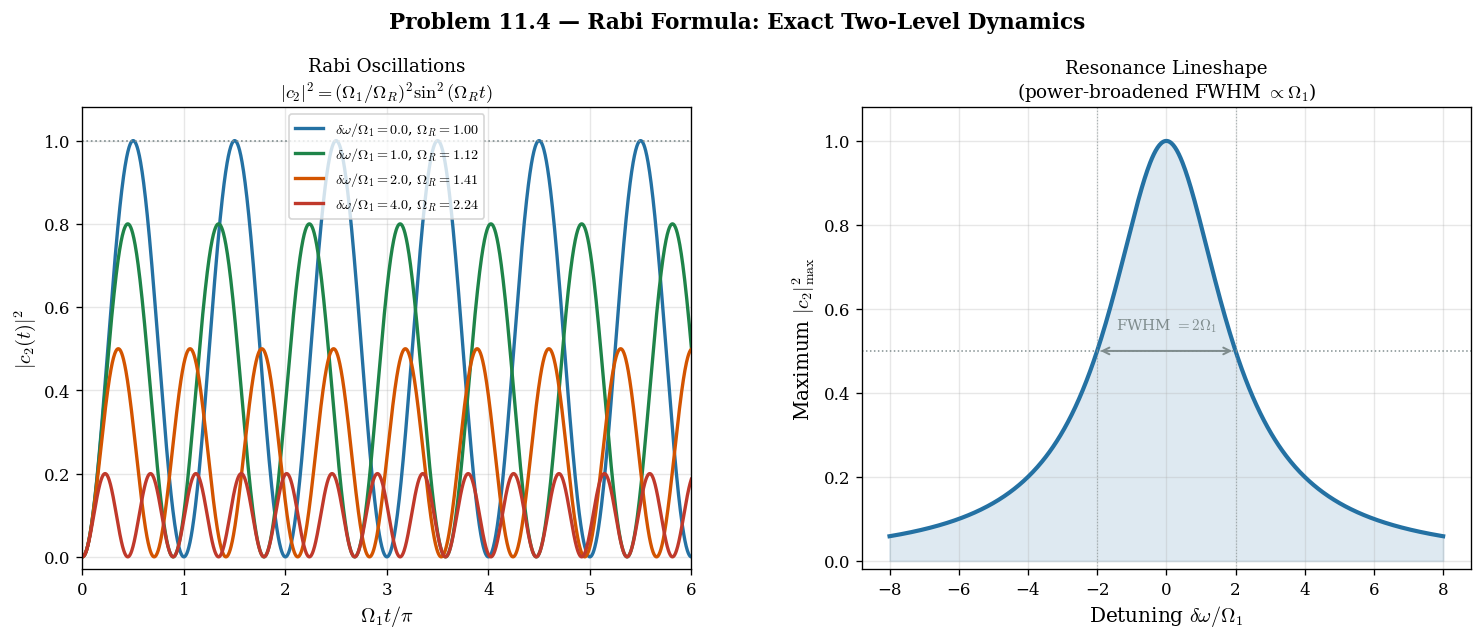

In [2]:
# Problem 11.4: Rabi formula -- exact two-level dynamics
hbar = 1.0; Omega1 = 1.0
t = np.linspace(0, 6*np.pi, 2000)

def rabi(t, dw, O1=1.0):
    OR = np.sqrt((dw/2)**2 + O1**2)
    return O1**2/OR**2 * np.sin(OR*t)**2

# Physics checks
t_pi = np.pi/(2*Omega1)
print(f'On resonance, |c2|^2 at t=pi/2Omega1 = {rabi(t_pi, 0.0):.6f}  (expect 1.0)')
dw_test = 4.0
P_max_expected = Omega1**2/((dw_test/2)**2+Omega1**2)
print(f'Off-resonance max |c2|^2 (dw={dw_test}) = {rabi(t,dw_test).max():.4f}  '
      f'(expect {P_max_expected:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.08, right=0.97, wspace=0.28)

# Left: |c2|^2 vs t for several detunings
ax = axes[0]
detunings = [0.0, 1.0, 2.0, 4.0]
cols_dw = [BLUE, GREEN, ORG, RED]
for dw, c in zip(detunings, cols_dw):
    OR = np.sqrt((dw/2)**2 + Omega1**2)
    ax.plot(t/np.pi, rabi(t, dw), color=c, lw=2,
            label=fr'$\delta\omega/\Omega_1={dw}$, $\Omega_R={OR:.2f}$')
ax.axhline(1.0, color=GRAY, ls=':', lw=1)
ax.set_xlabel(r'$\Omega_1 t / \pi$', labelpad=3)
ax.set_ylabel(r'$|c_2(t)|^2$')
ax.set_title('Rabi Oscillations\n'
              r'$|c_2|^2 = (\Omega_1/\Omega_R)^2\sin^2(\Omega_R t)$', fontsize=11)
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)
ax.set_xlim(0, t[-1]/np.pi); ax.set_ylim(-0.03, 1.08)

# Right: resonance lineshape -- max |c2|^2 vs detuning
ax2 = axes[1]
dw_arr = np.linspace(-8, 8, 600)
P_max = Omega1**2/((dw_arr/2)**2 + Omega1**2)
ax2.plot(dw_arr, P_max, color=BLUE, lw=2.5)
ax2.fill_between(dw_arr, P_max, alpha=0.15, color=BLUE)
ax2.axhline(0.5, color=GRAY, ls=':', lw=0.9)
ax2.axvline(-2, color=GRAY, ls=':', lw=0.7, alpha=0.6)
ax2.axvline( 2, color=GRAY, ls=':', lw=0.7, alpha=0.6)
ax2.annotate('', xy=(2,0.5), xytext=(-2,0.5),
              arrowprops=dict(arrowstyle='<->', color=GRAY, lw=1.2))
ax2.text(0, 0.55, r'FWHM $= 2\Omega_1$', color=GRAY, ha='center', fontsize=9)
ax2.set_xlabel(r'Detuning $\delta\omega / \Omega_1$', labelpad=3)
ax2.set_ylabel(r'Maximum $|c_2|^2_{\rm max}$')
ax2.set_title('Resonance Lineshape\n'
              r'(power-broadened FWHM $\propto\Omega_1$)', fontsize=11)
ax2.grid(True, alpha=0.3); ax2.set_ylim(-0.02, 1.08)

plt.suptitle('Problem 11.4 — Rabi Formula: Exact Two-Level Dynamics',
              fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_11_4.png')); plt.show()


---
## Problem 11.10 — Einstein A and B Coefficients {#md_11_10}

$$B_{ab}=B_{ba}=\frac{\pi|\wp|^2}{3\epsilon_0\hbar^2}, \qquad A=\frac{\omega_{ba}^3|\wp|^2}{3\pi\epsilon_0\hbar c^3}, \qquad \frac{A}{B}=\frac{\hbar\omega^3}{\pi^2c^3}$$

Derived from the equilibrium balance: $B_{ba}u N_a = (B_{ab}u + A)N_b$ combined with the Boltzmann ratio $N_b/N_a = e^{-\hbar\omega/k_BT}$ must reproduce Planck's law for $u(\omega)$.

Max difference between derived and Planck (normalised): 0.00e+00  (expect ~0)


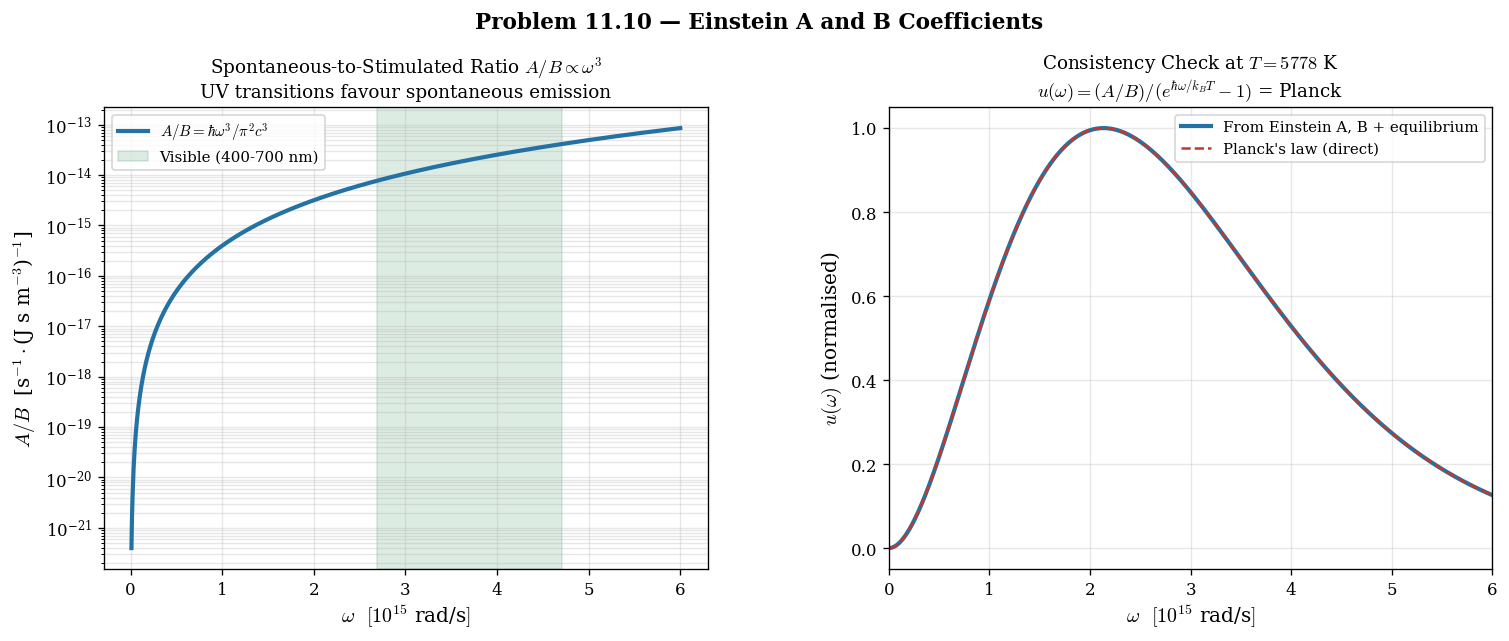

In [3]:
# Problem 11.10: Einstein A and B coefficients from thermal equilibrium
hbar = 1.054571817e-34; c = 2.99792458e8
kB = 1.380649e-23

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.08, right=0.97, wspace=0.30)

# Left: A/B ratio vs omega, with visible band marked
omega = np.linspace(1e13, 6e15, 1000)
AB_ratio = hbar*omega**3/(np.pi**2*c**3)
ax = axes[0]
ax.semilogy(omega/1e15, AB_ratio, color=BLUE, lw=2.5,
            label=r'$A/B = \hbar\omega^3/\pi^2 c^3$')
ov_lo = 2*np.pi*c/700e-9; ov_hi = 2*np.pi*c/400e-9
ax.axvspan(ov_lo/1e15, ov_hi/1e15, alpha=0.15, color=GREEN, label='Visible (400-700 nm)')
ax.set_xlabel(r'$\omega$  $[10^{15}$ rad/s$]$', labelpad=3)
ax.set_ylabel(r'$A/B$  [s$^{-1}\cdot$(J s m$^{-3}$)$^{-1}$]')
ax.set_title(r'Spontaneous-to-Stimulated Ratio $A/B\propto\omega^3$' + '\n'
             'UV transitions favour spontaneous emission', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')

# Right: equilibrium check -- Planck law derived from A, B
ax2 = axes[1]
T = 5778.0
x = np.clip(hbar*omega/(kB*T), 0, 500)
# Equilibrium balance: B u N_a = (B u + A) N_b, with N_b/N_a = exp(-hbar w/kT)
# => u = (A/B) / (e^{hbar w/kT} - 1)   -- this IS Planck's law
u_derived = AB_ratio / (np.exp(x) - 1)
# Direct Planck formula for comparison
u_planck = (hbar*omega**3/(np.pi**2*c**3)) / (np.exp(hbar*omega/(kB*T)) - 1)
ax2.plot(omega/1e15, u_derived/u_derived.max(), color=BLUE, lw=2.5,
         label='From Einstein A, B + equilibrium')
ax2.plot(omega/1e15, u_planck/u_planck.max(), color=RED, lw=1.5, ls='--',
         label="Planck's law (direct)")
ax2.set_xlabel(r'$\omega$  $[10^{15}$ rad/s$]$', labelpad=3)
ax2.set_ylabel(r'$u(\omega)$ (normalised)')
ax2.set_title(f'Consistency Check at $T={T:.0f}$ K\n'
              r'$u(\omega)=(A/B)/(e^{\hbar\omega/k_BT}-1)$ = Planck', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 6)

diff = np.max(np.abs(u_derived/u_derived.max() - u_planck/u_planck.max()))
print(f'Max difference between derived and Planck (normalised): {diff:.2e}  (expect ~0)')

plt.suptitle('Problem 11.10 — Einstein A and B Coefficients',
              fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_11_10.png')); plt.show()


---
## Problem 11.15 — Fermi's Golden Rule Derivation {#md_11_15}

$$\frac{\sin^2(\alpha t/2)}{(\alpha/2)^2}\;\xrightarrow{t\to\infty}\;2\pi t\,\delta(\alpha)$$

As $t$ increases, this function becomes sharply peaked at $\alpha=0$ (energy conservation) with area $\propto t$, giving a *constant* transition rate $\Gamma = \frac{2\pi}{\hbar}|H'_{fi}|^2\rho(E_f)$.

Max relative error vs 2*pi*t: 6.33e-03  (expect small)


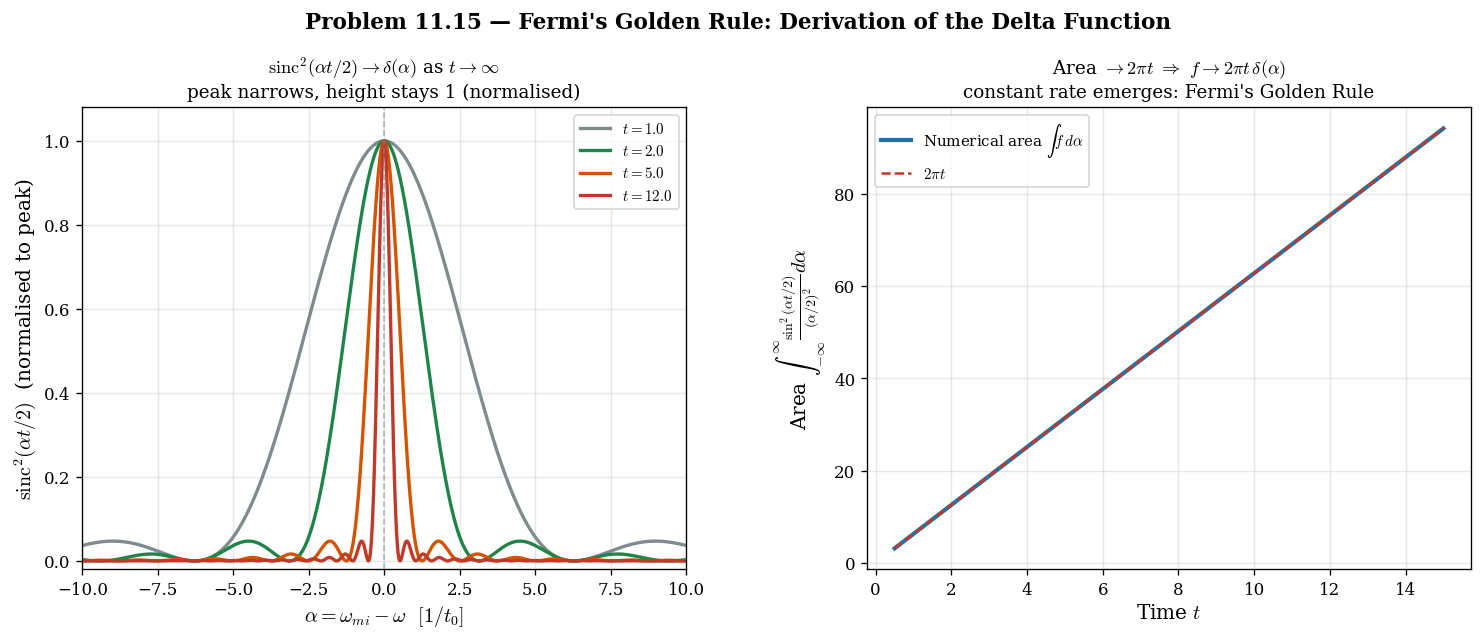

In [4]:
# Problem 11.15: sinc^2 -> delta function as t -> infinity
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.08, right=0.97, wspace=0.30)

# Left: sinc^2(alpha t/2) for increasing t, each normalised to its own peak
ax = axes[0]
alpha = np.sort(np.concatenate([
    np.linspace(-10, 10, 3000),
    np.linspace(-0.3, 0.3, 800),   # dense sampling near the peak
]))
t_vals = [1.0, 2.0, 5.0, 12.0]
cols_t = [GRAY, GREEN, ORG, RED]
for ti, c in zip(t_vals, cols_t):
    arg = alpha * ti / 2
    sinc2 = np.where(np.abs(arg) < 1e-9, 1.0, (np.sin(arg)/arg)**2)
    ax.plot(alpha, sinc2, color=c, lw=2, label=fr'$t={ti}$')
ax.axvline(0, color=GRAY, ls='--', lw=1, alpha=0.6)
ax.set_xlabel(r'$\alpha = \omega_{mi}-\omega$  $[1/t_0]$', labelpad=3)
ax.set_ylabel(r'$\mathrm{sinc}^2(\alpha t/2)$  (normalised to peak)')
ax.set_title(r'$\mathrm{sinc}^2(\alpha t/2)\to\delta(\alpha)$ as $t\to\infty$' + '\n'
             'peak narrows, height stays 1 (normalised)', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim(-10, 10); ax.set_ylim(-0.02, 1.08)

# Right: area under sin^2(alpha t/2)/(alpha/2)^2 -- should grow as 2*pi*t
ax2 = axes[1]
t_arr = np.linspace(0.5, 15, 60)
areas = []
alpha_fine = np.linspace(-200, 200, 200000)
for ti in t_arr:
    arg = alpha_fine * ti/2
    f = np.where(np.abs(arg) < 1e-12, ti**2, np.sin(arg)**2/(alpha_fine/2)**2)
    areas.append(np.trapezoid(f, alpha_fine))
areas = np.array(areas)
ax2.plot(t_arr, areas, color=BLUE, lw=2.5, label=r'Numerical area $\int f\,d\alpha$')
ax2.plot(t_arr, 2*np.pi*t_arr, color=RED, lw=1.5, ls='--', label=r'$2\pi t$')
ax2.set_xlabel(r'Time $t$', labelpad=3)
ax2.set_ylabel(r'Area $\int_{-\infty}^{\infty}\frac{\sin^2(\alpha t/2)}{(\alpha/2)^2}d\alpha$')
ax2.set_title(r'Area $\to 2\pi t$ $\Rightarrow$ $f\to 2\pi t\,\delta(\alpha)$' + '\n'
              'constant rate emerges: Fermi\'s Golden Rule', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

err = np.max(np.abs(areas - 2*np.pi*t_arr)/(2*np.pi*t_arr))
print(f'Max relative error vs 2*pi*t: {err:.2e}  (expect small)')

plt.suptitle("Problem 11.15 — Fermi's Golden Rule: Derivation of the Delta Function",
              fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_11_15.png')); plt.show()


---
## Problem 11.16 — Density of States: 3D, 2D, 1D {#md_11_16}

$$\rho_{3D}(E)\propto\sqrt{E}, \qquad \rho_{2D}(E)=\text{const}, \qquad \rho_{1D}(E)\propto\frac{1}{\sqrt{E}}$$

Entering Fermi's Golden Rule $\Gamma=\frac{2\pi}{\hbar}|H'_{fi}|^2\rho(E_f)$, the dimensionality of the final-state continuum directly controls the transition rate's energy dependence — the 1D divergence at $E\to0$ is the van Hove singularity.

rho_3D(4)/rho_3D(1) = 1.9995496641187842   (expect sqrt(4)=2)
rho_1D(4)/rho_1D(1) = 0.5001126093263141   (expect 1/sqrt(4)=0.5)


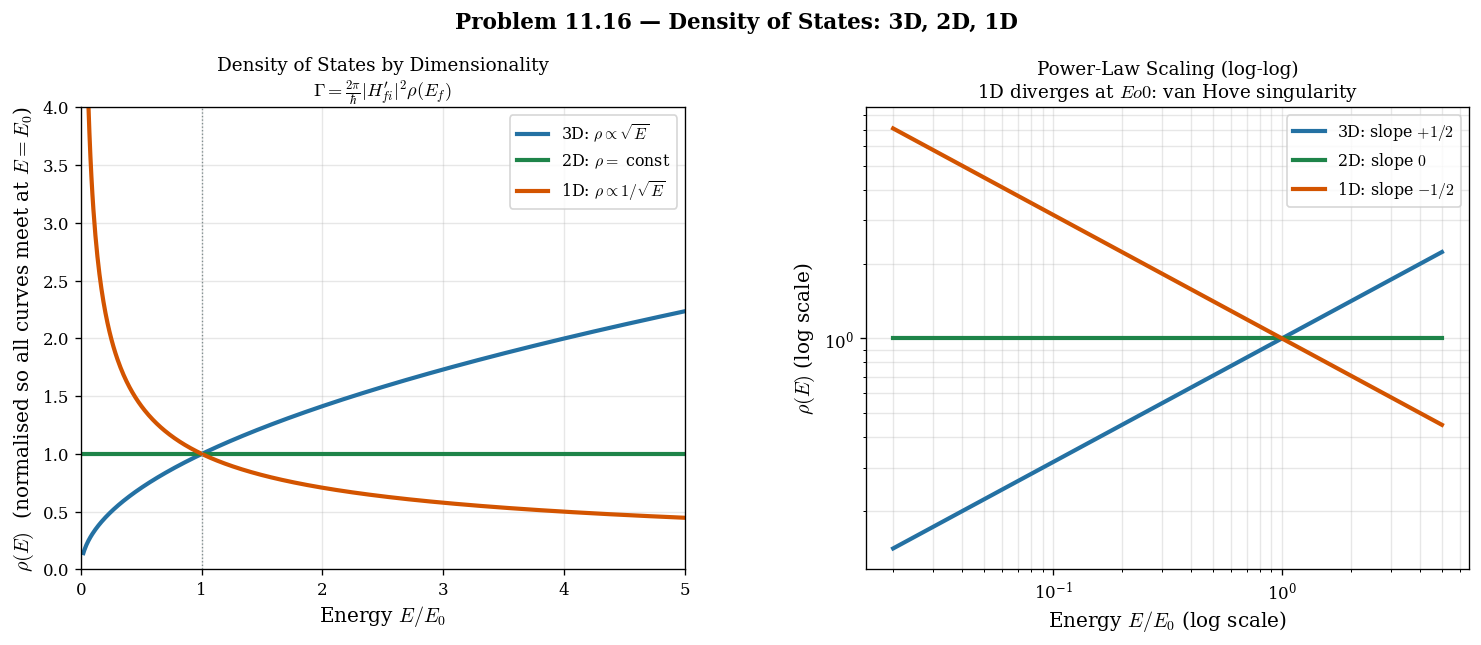

In [5]:
# Problem 11.16: Density of states for a free particle in 3D, 2D, 1D
# rho_3D(E) ~ sqrt(E)   (E = p^2/2m, dN/dE ~ p^2 dp/dE ~ sqrt(E))
# rho_2D(E) ~ const     (dN/dE ~ p dp/dE ~ const)
# rho_1D(E) ~ 1/sqrt(E) (dN/dE ~ dp/dE ~ 1/sqrt(E))

E_arr = np.linspace(0.02, 5, 600)
rho_3D = np.sqrt(E_arr)
rho_2D = np.ones_like(E_arr)
rho_1D = 1.0/np.sqrt(E_arr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.08, right=0.97, wspace=0.30)

# Left: rho(E) normalised at E=1
ax = axes[0]
ax.plot(E_arr, rho_3D/rho_3D[np.argmin(np.abs(E_arr-1))], color=BLUE,  lw=2.5,
        label=r'3D: $\rho\propto\sqrt{E}$')
ax.plot(E_arr, rho_2D/rho_2D[np.argmin(np.abs(E_arr-1))], color=GREEN, lw=2.5,
        label=r'2D: $\rho=$ const')
ax.plot(E_arr, rho_1D/rho_1D[np.argmin(np.abs(E_arr-1))], color=ORG,   lw=2.5,
        label=r'1D: $\rho\propto 1/\sqrt{E}$')
ax.axvline(1, color=GRAY, ls=':', lw=0.8)
ax.set_xlabel(r'Energy $E/E_0$', labelpad=3)
ax.set_ylabel(r'$\rho(E)$  (normalised so all curves meet at $E=E_0$)')
ax.set_title('Density of States by Dimensionality\n'
             r'$\Gamma=\frac{2\pi}{\hbar}|H_{fi}^{\prime}|^2\rho(E_f)$', fontsize=11)
ax.legend(fontsize=9.5); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 5); ax.set_ylim(0, 4)

# Right: log-log to show power laws clearly
ax2 = axes[1]
ax2.loglog(E_arr, rho_3D, color=BLUE,  lw=2.5, label=r'3D: slope $+1/2$')
ax2.loglog(E_arr, rho_2D, color=GREEN, lw=2.5, label=r'2D: slope $0$')
ax2.loglog(E_arr, rho_1D, color=ORG,   lw=2.5, label=r'1D: slope $-1/2$')
ax2.set_xlabel(r'Energy $E/E_0$ (log scale)', labelpad=3)
ax2.set_ylabel(r'$\rho(E)$ (log scale)')
ax2.set_title('Power-Law Scaling (log-log)\n'
              '1D diverges at $E\to0$: van Hove singularity', fontsize=11)
ax2.legend(fontsize=9.5); ax2.grid(True, alpha=0.3, which='both')

print('rho_3D(4)/rho_3D(1) =', rho_3D[np.argmin(np.abs(E_arr-4))]/rho_3D[np.argmin(np.abs(E_arr-1))],
      '  (expect sqrt(4)=2)')
print('rho_1D(4)/rho_1D(1) =', rho_1D[np.argmin(np.abs(E_arr-4))]/rho_1D[np.argmin(np.abs(E_arr-1))],
      '  (expect 1/sqrt(4)=0.5)')

plt.suptitle('Problem 11.16 — Density of States: 3D, 2D, 1D',
              fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_11_16.png')); plt.show()


---
## Problem 11.18 — Coherent Rabi vs Incoherent FGR Decay {#md_11_18}

A two-level system coupled to a *single* final state oscillates coherently (Rabi). Coupled to a *continuum* of final states with random detunings, the oscillations dephase and the population grows monotonically — the onset of Fermi's Golden Rule's exponential decay law $1-e^{-\Gamma t}$.

Plateau value (continuum average): 0.3696
Single-state Rabi oscillates between 0 and 1 (no plateau)


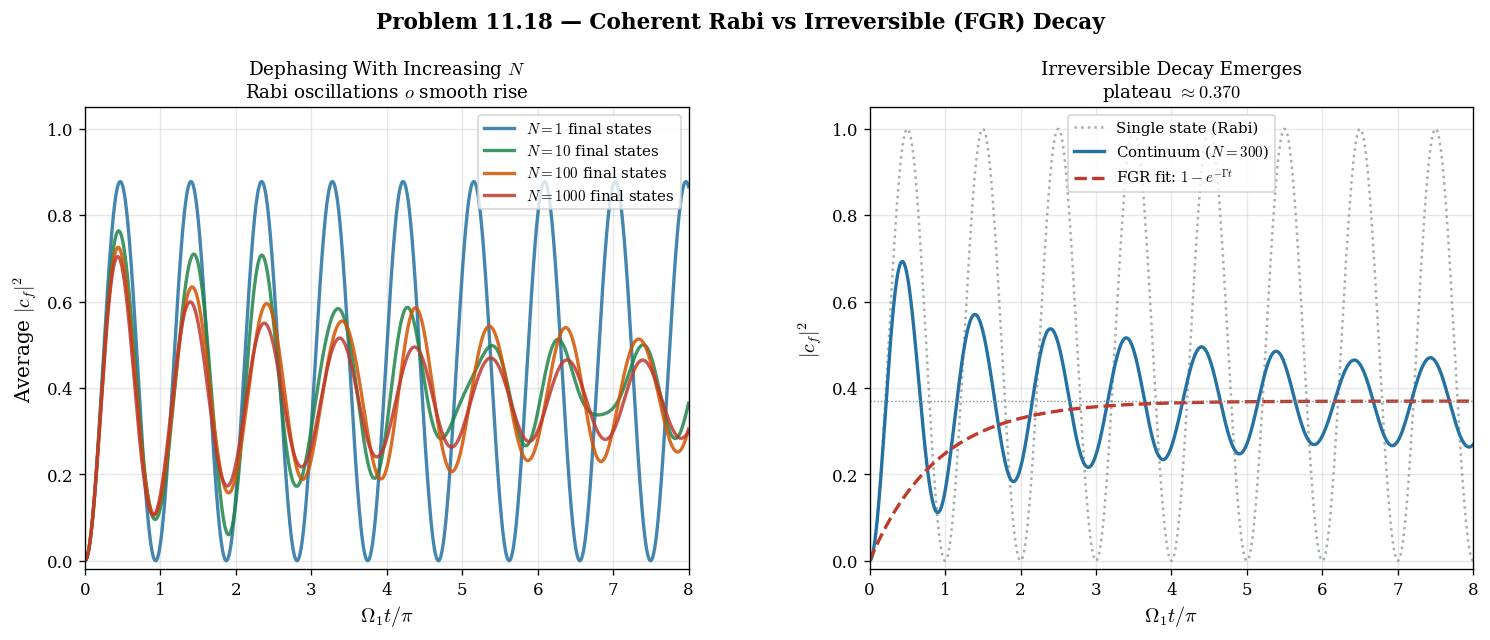

In [6]:
# Problem 11.18: Coherent Rabi (2 levels) vs irreversible FGR decay (continuum)
np.random.seed(42)
Omega1 = 1.0
t_plot = np.linspace(0, 8*np.pi, 2000)

# Coherent: single final state
P_rabi = np.sin(Omega1 * t_plot)**2

# Continuum: sum over many final states with Gaussian-distributed detunings
N_list = [1, 10, 100, 1000]
sigma_E = 1.5

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.08, right=0.97, wspace=0.30)

# Left: P(t) for increasing N
ax = axes[0]
cols_N = [BLUE, GREEN, ORG, RED]
for N, c in zip(N_list, cols_N):
    dw_arr = np.random.normal(0, sigma_E, N)
    P_sum = np.zeros_like(t_plot)
    for dw in dw_arr:
        OR = np.sqrt((dw/2)**2 + Omega1**2)
        P_sum += Omega1**2/OR**2 * np.sin(OR*t_plot)**2
    P_sum /= N
    ax.plot(t_plot/np.pi, P_sum, color=c, lw=2, label=fr'$N={N}$ final states', alpha=0.85)
ax.set_xlabel(r'$\Omega_1 t/\pi$', labelpad=3)
ax.set_ylabel(r'Average $|c_f|^2$')
ax.set_title('Dephasing With Increasing $N$\n'
             'Rabi oscillations $\to$ smooth rise', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim(0, t_plot[-1]/np.pi); ax.set_ylim(-0.02, 1.05)

# Right: N=300 vs exponential FGR fit
ax2 = axes[1]
N_big = 300
dw_arr = np.random.normal(0, sigma_E, N_big)
P_sum = np.zeros_like(t_plot)
for dw in dw_arr:
    OR = np.sqrt((dw/2)**2 + Omega1**2)
    P_sum += Omega1**2/OR**2 * np.sin(OR*t_plot)**2
P_sum /= N_big

plateau = P_sum[-len(P_sum)//4:].mean()
Gamma_eff = 2*Omega1**2 * np.sqrt(2*np.pi)/sigma_E   # ~ 2*pi*|V|^2*rho
P_fgr = plateau*(1-np.exp(-t_plot/(2*np.pi/Gamma_eff*sigma_E)))

ax2.plot(t_plot/np.pi, P_rabi, color=GRAY, lw=1.5, ls=':', alpha=0.7,
         label='Single state (Rabi)')
ax2.plot(t_plot/np.pi, P_sum, color=BLUE, lw=2, label=fr'Continuum ($N={N_big}$)')
ax2.plot(t_plot/np.pi, P_fgr, color=RED, lw=2, ls='--',
         label=r'FGR fit: $1-e^{-\Gamma t}$')
ax2.axhline(plateau, color=GRAY, lw=0.8, ls=':')
ax2.set_xlabel(r'$\Omega_1 t/\pi$', labelpad=3)
ax2.set_ylabel(r'$|c_f|^2$')
ax2.set_title('Irreversible Decay Emerges\n'
              r'plateau $\approx %.3f$' % plateau, fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, t_plot[-1]/np.pi); ax2.set_ylim(-0.02, 1.05)

print(f'Plateau value (continuum average): {plateau:.4f}')
print(f'Single-state Rabi oscillates between 0 and 1 (no plateau)')

plt.suptitle('Problem 11.18 — Coherent Rabi vs Irreversible (FGR) Decay',
              fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_11_18.png')); plt.show()


---
## Problem 11.20 — Berry Phase: Spin-½ in a Rotating Field {#md_11_20}

$$\gamma_\pm = \mp\frac{\Omega_{\rm solid}}{2}, \qquad \Omega_{\rm solid} = 2\pi(1-\cos\theta_0)$$

For one full revolution of $\mathbf{B}(t)$ around a cone of half-angle $\theta_0$, the Berry phase equals minus half the solid angle subtended — purely geometric, independent of how fast the field rotates (as long as adiabatic).

gamma_+ at theta0=90°:  -1.0031 pi  (expect -0.5)
gamma_+ at theta0=180°: -2.0000 pi  (expect -1.0)
gamma_+ + gamma_- = 0.0000 pi  (expect 0)


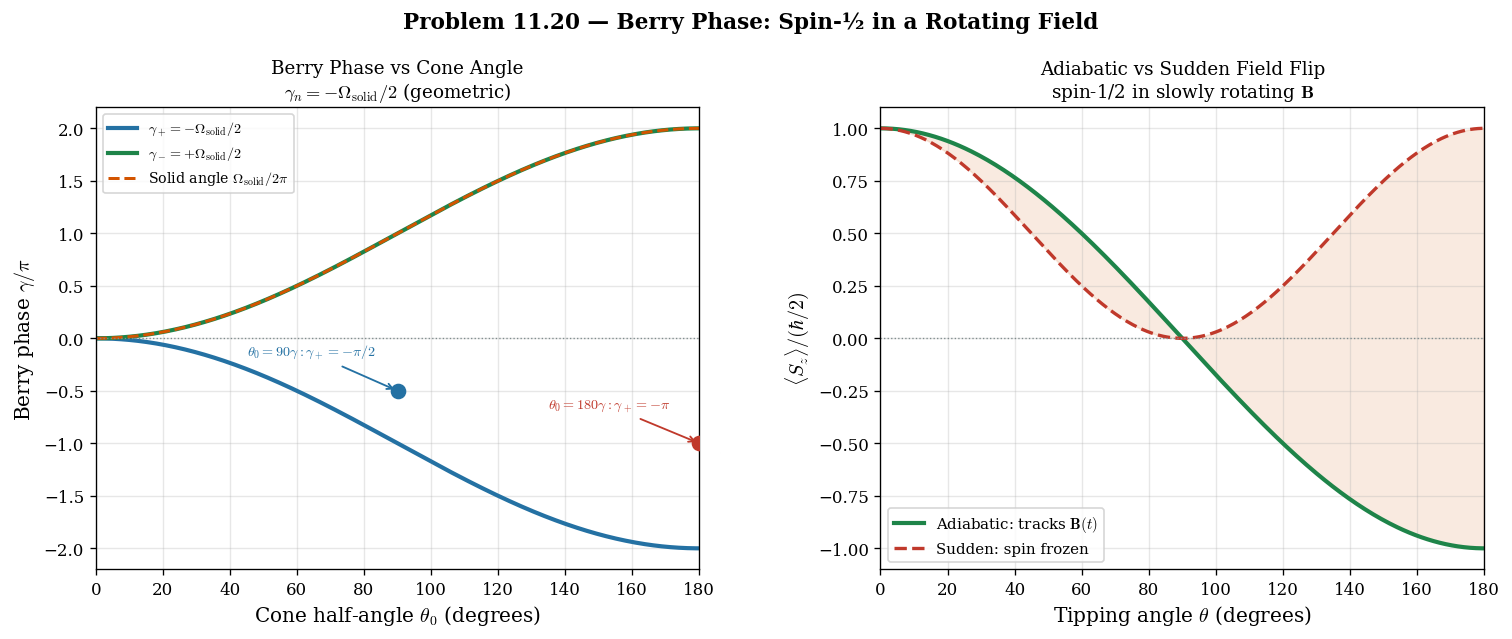

In [7]:
# Problem 11.20: Berry phase for spin-1/2 in adiabatically rotating B field
theta0 = np.linspace(0, np.pi, 500)
Omega_solid = 2*np.pi*(1-np.cos(theta0))
gamma_p = -Omega_solid/2
gamma_m =  Omega_solid/2

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.08, right=0.97, wspace=0.30)

# Left: Berry phase vs cone half-angle
ax = axes[0]
ax.plot(np.degrees(theta0), gamma_p/np.pi, color=BLUE,  lw=2.5,
        label=r'$\gamma_+=-\Omega_{\rm solid}/2$')
ax.plot(np.degrees(theta0), gamma_m/np.pi, color=GREEN, lw=2.5,
        label=r'$\gamma_-=+\Omega_{\rm solid}/2$')
ax.plot(np.degrees(theta0), Omega_solid/(2*np.pi), color=ORG, lw=1.8, ls='--',
        label=r'Solid angle $\Omega_{\rm solid}/2\pi$')
ax.axhline(0, color=GRAY, lw=0.8, ls=':')

for th_deg, gv, c, lbl in [(90,-0.5,BLUE,r'$\theta_0=90°:\gamma_+=-\pi/2$'),
                            (180,-1.0,RED,r'$\theta_0=180°:\gamma_+=-\pi$')]:
    ax.scatter([th_deg],[gv], color=c, s=70, zorder=5)
    ax.annotate(lbl, xy=(th_deg,gv), xytext=(th_deg-45,gv+0.33),
                fontsize=8.5, color=c, arrowprops=dict(arrowstyle='->', color=c, lw=1.1))

ax.set_xlabel(r'Cone half-angle $\theta_0$ (degrees)', labelpad=3)
ax.set_ylabel(r'Berry phase $\gamma/\pi$')
ax.set_title('Berry Phase vs Cone Angle\n'
             r'$\gamma_n=-\Omega_{\rm solid}/2$ (geometric)', fontsize=11)
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3); ax.set_xlim(0, 180)

# Right: spin <Sz> tracks B(t) -- adiabatic vs sudden flip
ax2 = axes[1]
theta_path = np.linspace(0, np.pi, 300)
Sz_adiab  = np.cos(theta_path)
P_stay    = np.cos(theta_path/2)**2
Sz_sudden = P_stay*np.cos(theta_path) + (1-P_stay)*(-np.cos(theta_path))

ax2.plot(np.degrees(theta_path), Sz_adiab,  color=GREEN, lw=2.5,
         label=r'Adiabatic: tracks $\mathbf{B}(t)$')
ax2.plot(np.degrees(theta_path), Sz_sudden, color=RED,   lw=2, ls='--',
         label='Sudden: spin frozen')
ax2.fill_between(np.degrees(theta_path), Sz_adiab, Sz_sudden, alpha=0.12, color=ORG)
ax2.axhline(0, color=GRAY, lw=0.8, ls=':')
ax2.set_xlabel(r'Tipping angle $\theta$ (degrees)', labelpad=3)
ax2.set_ylabel(r'$\langle S_z\rangle/(\hbar/2)$')
ax2.set_title('Adiabatic vs Sudden Field Flip\n'
              r'spin-1/2 in slowly rotating $\mathbf{B}$', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 180); ax2.set_ylim(-1.1, 1.1)

print(f'gamma_+ at theta0=90°:  {gamma_p[250]/np.pi:.4f} pi  (expect -0.5)')
print(f'gamma_+ at theta0=180°: {gamma_p[-1]/np.pi:.4f} pi  (expect -1.0)')
print(f'gamma_+ + gamma_- = {(gamma_p[-1]+gamma_m[-1])/np.pi:.4f} pi  (expect 0)')

plt.suptitle('Problem 11.20 — Berry Phase: Spin-½ in a Rotating Field',
              fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_11_20.png')); plt.show()


---
## Problem 11.22 — Landau-Zener Transition Probability {#md_11_22}

$$P_{LZ}=e^{-\pi\Delta^2/2\hbar v}$$

At an avoided crossing with gap $\Delta$, a parameter swept at rate $v$: slow sweep ($v\to0$) keeps the system on the adiabatic branch ($P_{LZ}\to0$); fast sweep ($v\to\infty$) causes a sudden jump to the other branch ($P_{LZ}\to1$).

P_LZ(v=0.1) = 1.51e-07  (expect ~0, adiabatic)
P_LZ(v=10)  = 0.8546  (expect close to 1, sudden)


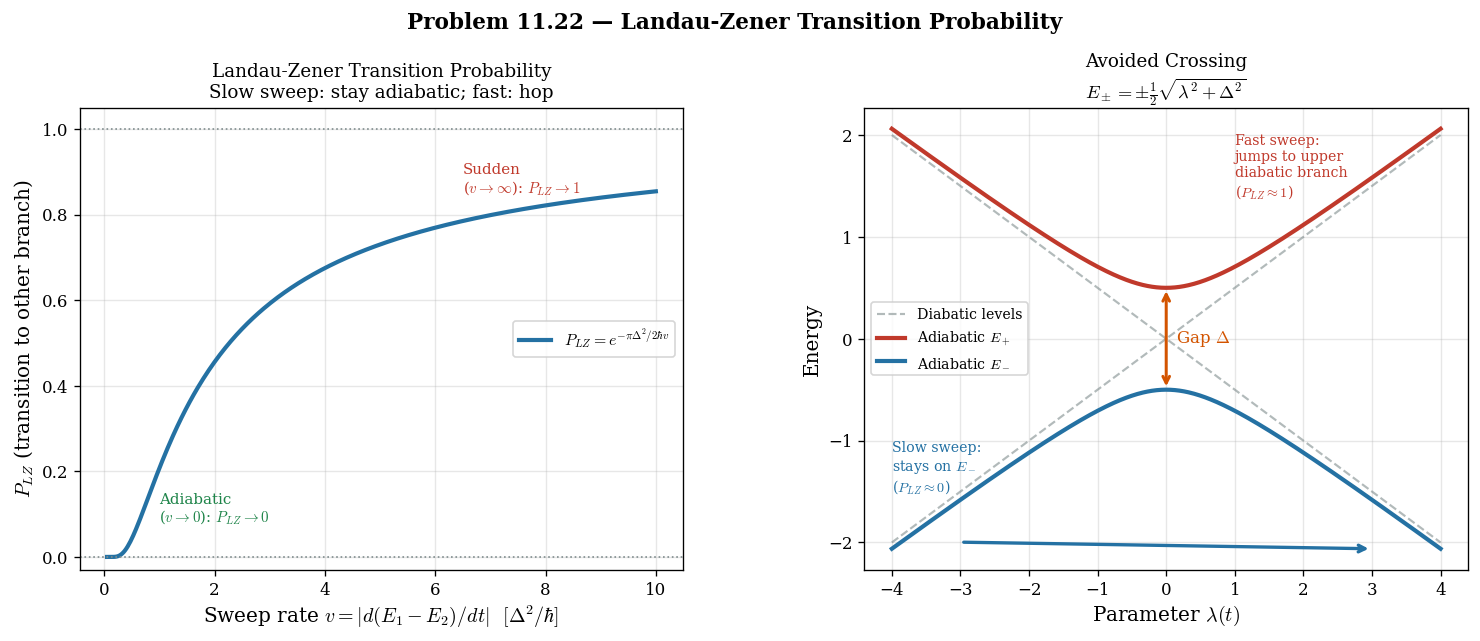

In [8]:
# Problem 11.22: Landau-Zener transition probability
Delta = 1.0
v_arr = np.linspace(0.05, 10, 400)
P_LZ = np.exp(-np.pi*Delta**2/(2*v_arr))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.08, right=0.97, wspace=0.30)

# Left: P_LZ vs sweep rate v
ax = axes[0]
ax.plot(v_arr, P_LZ, color=BLUE, lw=2.5,
        label=r'$P_{LZ}=e^{-\pi\Delta^2/2\hbar v}$')
ax.axhline(1.0, color=GRAY, ls=':', lw=1)
ax.axhline(0.0, color=GRAY, ls=':', lw=1)
ax.text(1, 0.08, 'Adiabatic\n($v\\to0$): $P_{LZ}\\to0$', color=GREEN, fontsize=9)
ax.text(6.5, 0.85, 'Sudden\n($v\\to\\infty$): $P_{LZ}\\to1$', color=RED, fontsize=9)
ax.set_xlabel(r'Sweep rate $v = |d(E_1-E_2)/dt|$  $[\Delta^2/\hbar]$', labelpad=3)
ax.set_ylabel(r'$P_{LZ}$ (transition to other branch)')
ax.set_title('Landau-Zener Transition Probability\n'
             'Slow sweep: stay adiabatic; fast: hop', fontsize=11)
ax.legend(fontsize=9.5); ax.grid(True, alpha=0.3); ax.set_ylim(-0.03, 1.05)

# Right: avoided crossing diagram with adiabatic/sudden trajectories
ax2 = axes[1]
lam = np.linspace(-4, 4, 600)
E_plus  =  0.5*np.sqrt(lam**2 + Delta**2)
E_minus = -0.5*np.sqrt(lam**2 + Delta**2)
ax2.plot(lam,  lam/2, color=GRAY, lw=1.3, ls='--', alpha=0.6, label='Diabatic levels')
ax2.plot(lam, -lam/2, color=GRAY, lw=1.3, ls='--', alpha=0.6)
ax2.plot(lam, E_plus,  color=RED,  lw=2.5, label=r'Adiabatic $E_+$')
ax2.plot(lam, E_minus, color=BLUE, lw=2.5, label=r'Adiabatic $E_-$')
ax2.annotate('', xy=(0,Delta/2), xytext=(0,-Delta/2),
              arrowprops=dict(arrowstyle='<->', color=ORG, lw=1.8))
ax2.text(0.15, 0, r'Gap $\Delta$', color=ORG, fontsize=10, va='center')

# Trajectories: adiabatic (stays on E_-), sudden (jumps to E_+ diabatic)
ax2.annotate('', xy=(3, E_minus[-1]), xytext=(-3, E_minus[10]),
              arrowprops=dict(arrowstyle='->', color=BLUE, lw=2,
                               connectionstyle='arc3,rad=0.0'))
ax2.text(-4, -1.5, 'Slow sweep:\nstays on $E_-$\n($P_{LZ}\\approx0$)',
         color=BLUE, fontsize=8.5)
ax2.text(1.0, 1.4, 'Fast sweep:\njumps to upper\ndiabatic branch\n($P_{LZ}\\approx1$)',
         color=RED, fontsize=8.5)

ax2.set_xlabel(r'Parameter $\lambda(t)$', labelpad=3)
ax2.set_ylabel('Energy')
ax2.set_title('Avoided Crossing\n'
              r'$E_\pm=\pm\frac{1}{2}\sqrt{\lambda^2+\Delta^2}$', fontsize=11)
ax2.legend(fontsize=8.5, loc='center left'); ax2.grid(True, alpha=0.3)

print(f'P_LZ(v=0.1) = {np.exp(-np.pi*Delta**2/(2*0.1)):.2e}  (expect ~0, adiabatic)')
print(f'P_LZ(v=10)  = {np.exp(-np.pi*Delta**2/(2*10)):.4f}  (expect close to 1, sudden)')

plt.suptitle('Problem 11.22 — Landau-Zener Transition Probability',
              fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_11_22.png')); plt.show()


---
## Save All Figures & Download as ZIP

In [9]:
import os, zipfile

save_dir = 'ch11_figures'
os.makedirs(save_dir, exist_ok=True)

for fig, fname in figures:
    path = os.path.join(save_dir, fname)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')

zip_name = 'ch11_figures.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fig, fname in figures:
        zf.write(os.path.join(save_dir, fname), fname)
print(f'Zip: {zip_name},  Files: {[f for _,f in figures]}')

try:
    from google.colab import files
    files.download(zip_name)
    print('Download started.')
except ImportError:
    print(f'Not in Colab — saved locally as: {zip_name}')


Saved: ch11_figures/fig_11_4.png
Saved: ch11_figures/fig_11_10.png
Saved: ch11_figures/fig_11_15.png
Saved: ch11_figures/fig_11_16.png
Saved: ch11_figures/fig_11_18.png
Saved: ch11_figures/fig_11_20.png
Saved: ch11_figures/fig_11_22.png
Zip: ch11_figures.zip,  Files: ['fig_11_4.png', 'fig_11_10.png', 'fig_11_15.png', 'fig_11_16.png', 'fig_11_18.png', 'fig_11_20.png', 'fig_11_22.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
